In [1]:
import sys
import os

from pathlib import Path
sys.path.append(str(Path().resolve().parent))
str(Path().resolve().parent)

ROOT = Path(os.getcwd()).resolve().parent
ROOT

PosixPath('/Users/mohamedmafaz/Desktop/CFD_DiT')

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import pandas as pd
from scipy.interpolate import griddata
import matplotlib.ticker as tkr

from DDPM import LinearNoiseScheduler
from DiT_model import DiT
from VAE import VAE

In [3]:
import json
with open("../config/config.json", "r") as file:
    config = json.load(file)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vae = VAE(device = device, freeze = True, scaling_factor = config["VAE"]["scaling_factor"], path = f"{ROOT}/pretrained/sd-vae-ft-mse").to(device)

num_timesteps = 1000
beta_start    = 0.0001
beta_end      = 0.02


scheduler = LinearNoiseScheduler(num_timesteps  = num_timesteps,
                                     beta_start = beta_start,
                                     beta_end   = beta_end)


In [5]:
dit = DiT(d_model          = config["DiT"]["d_model"],
          g_channels       = config["DiT"]["g_channels"],
          grid_size        = config["DiT"]["grid_size"],
          patch_size       = config["DiT"]["patch_size"],
          timestep_emb_dim = config["DiT"]["timestep_emb_dim"],
          number_emb_dim   = config["DiT"]["number_emb_dim"],
          num_layers       = config["DiT"]["num_layers"],
          num_heads        = config["DiT"]["num_heads"])

vae.eval()
dit.eval()

vae.load_state_dict(torch.load(f"{ROOT}/models/VAE.pth", map_location = device))
dit.load_state_dict(torch.load(f'{ROOT}/models/DiT.pth', map_location = device))

<All keys matched successfully>

In [6]:
@torch.no_grad()
def sample(latent_grid_size: int, dit, vae, device, scheduler, number, **kwargs):
    xt = torch.randn((1, 4, latent_grid_size, latent_grid_size)).to(device)

    for i in tqdm(reversed(range(1000))):
        noise_pred = dit(xt, 
                         torch.as_tensor(i).unsqueeze(0).to(device), 
                         torch.as_tensor(number).unsqueeze(0).to(device))

        xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))

    img_tensor = vae.decode(x0_pred)
    return img_tensor

In [32]:
@torch.no_grad()
def sample_ddim(latent_grid_size, dit, vae, device, scheduler, number, num_steps=1000, seed=None):
    if seed is not None:
        torch.manual_seed(seed)

    xt = torch.randn((1, 4, latent_grid_size, latent_grid_size)).to(device)

    # e.g. [999, 979, 959, ..., 19, -1]  (evenly spaced, descending)
    step_indices = torch.linspace(0, 999, num_steps).long().flip(0)
    step_indices = torch.cat([step_indices, torch.tensor([-1])])  # -1 = terminal, x0

    for idx in tqdm(range(len(step_indices) - 1)):
        t = step_indices[idx].item()
        t_prev = step_indices[idx + 1].item()

        noise_pred = dit(xt,
                          torch.as_tensor(t).unsqueeze(0).to(device),
                          torch.as_tensor(number).unsqueeze(0).to(device))

        xt, x0_pred = scheduler.ddim_step(xt, noise_pred, t, t_prev, eta=0.0)

    img_tensor = vae.decode(x0_pred)
    return img_tensor

In [40]:
def predict(re_value, sample_fn, 
            re_mean, re_std, 
            u_mean, u_std, 
            v_mean, v_std, 
            P_mean, P_std, 
            grid_size,
            device="cpu", plot: bool = True, **kwargs):
    '''
    magic
    '''
        
    # img = sample_fn(32, dit, vae, device, scheduler, re_value)
    img = sample_fn(32, dit, vae, device, scheduler, (re_value - re_mean) / re_std)

    img_np = np.array(img)

    img_np = img_np[0]


    u = (img_np[0] * u_std) + u_mean
    v = (img_np[1] * v_std) + v_mean
    p = (img_np[2] * P_std) + P_mean

    mag = np.sqrt(u**2 + v**2)

    du_dx = np.gradient(u, axis = 1) # derivative along x (cols)
    du_dy = np.gradient(u, axis = 0)
    dv_dy = np.gradient(v, axis = 0) # derivative along y (rows)
    dv_dx = np.gradient(v, axis = 1)


    d2u_dx2 = np.gradient(du_dx, axis = 1)
    d2u_dy2 = np.gradient(du_dy, axis = 0)
    d2v_dy2 = np.gradient(dv_dy, axis = 0)
    d2v_dx2 = np.gradient(dv_dx, axis = 1)


    dP_dx = np.gradient(p, axis = 1)
    dP_dy = np.gradient(p, axis = 0)


    momentum_res_x = (1 * ((u * du_dx) + (v * du_dy))) + dP_dx + (1/re_value) * (d2u_dx2 + d2u_dy2)
    momentum_res_y = (1 * ((u * dv_dx) + (v * dv_dy))) + dP_dy + (1/re_value) * (d2v_dx2 + d2v_dy2)

    momentum_res =  (momentum_res_x ** 2 + momentum_res_y ** 2)**0.5

    divergence = du_dx + dv_dy

    if plot:
        # u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
        # v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

        # plot
        x_grid = np.linspace(0, 1, grid_size)
        y_grid = np.linspace(0, 1, grid_size)


        fig, axes = plt.subplots(1, 6, figsize=(30, 5))

        # u
        c0 = axes[0].contourf(x_grid, y_grid, u, levels=300, cmap="jet")
        fig.colorbar(c0, ax=axes[0])
        axes[0].set_title("u (m/s)")

        # v
        c1 = axes[1].contourf(x_grid, y_grid, v, levels=300, cmap="jet")
        fig.colorbar(c1, ax=axes[1])
        axes[1].set_title("v (m/s)")

        # p
        c2 = axes[2].contourf(x_grid, y_grid, p, levels=300, cmap="jet")
        fig.colorbar(c2, ax=axes[2])
        axes[2].set_title("P (Pa)")

        # mag
        c3 = axes[3].contourf(x_grid, y_grid, mag, levels=300, cmap="jet")
        fig.colorbar(c3, ax=axes[3])
        axes[3].set_title("|U|")


        c4 = axes[4].contourf(x_grid, y_grid, divergence, levels=300, cmap="seismic")
        fig.colorbar(c4, ax=axes[4], label="∇·u")
        axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")

        div_m = axes[5].contourf(x_grid, y_grid, momentum_res, levels=300, cmap="seismic")
        plt.colorbar(div_m, ax=axes[5])
        axes[5].set_title(f"Momemtum residual mean: {momentum_res.mean():.4f}")
        axes[5].set_xlabel("x")
        axes[5].set_ylabel("y")

        plt.suptitle(f"Re = {re_value}")
        plt.tight_layout()
        plt.show()

    return u, v, p, divergence, momentum_res, mag

In [41]:
meta = config["Data"]['meta']
RE_MEAN = config["Stats"][meta]["Re_Mean"]
RE_STD = config["Stats"][meta]["Re_Std"]

U_MEAN = config["Stats"][meta]["U_MEAN"]
U_STD = config["Stats"][meta]["U_STD"]

V_MEAN = config["Stats"][meta]["V_MEAN"]
V_STD = config["Stats"][meta]["V_STD"]

P_MEAN = config["Stats"][meta]["P_MEAN"]
P_STD = config["Stats"][meta]["P_STD"]

In [63]:
import os
a = os.listdir(f"{ROOT}/Data/Problems/Lid_Driven_domain")
re_s = torch.tensor([float(i.split("_")[1].split(".csv")[0]) for i in a])
re_norm = (re_s - 1191.501250) / 739.827089
re_norm.min(), re_norm.max()

(tensor(-1.5991), tensor(1.7674))

In [62]:
a = os.listdir(f"{ROOT}/Data/Problems/Lid_Driven_domain")
re_s = torch.tensor([float(i.split("_")[1].split(".csv")[0]) for i in a])

print(f"Files in folder: {len(a)}")
print(f"Raw Re — min: {re_s.min():.1f}, max: {re_s.max():.1f}, mean: {re_s.mean():.1f}")
print(f"RE_MEAN from config: {RE_MEAN:.1f}, RE_STD: {RE_STD:.1f}")

Files in folder: 320
Raw Re — min: 8.4, max: 2499.1, mean: 1191.5
RE_MEAN from config: 23.0, RE_STD: 12.8


100%|██████████| 1000/1000 [00:49<00:00, 20.34it/s]


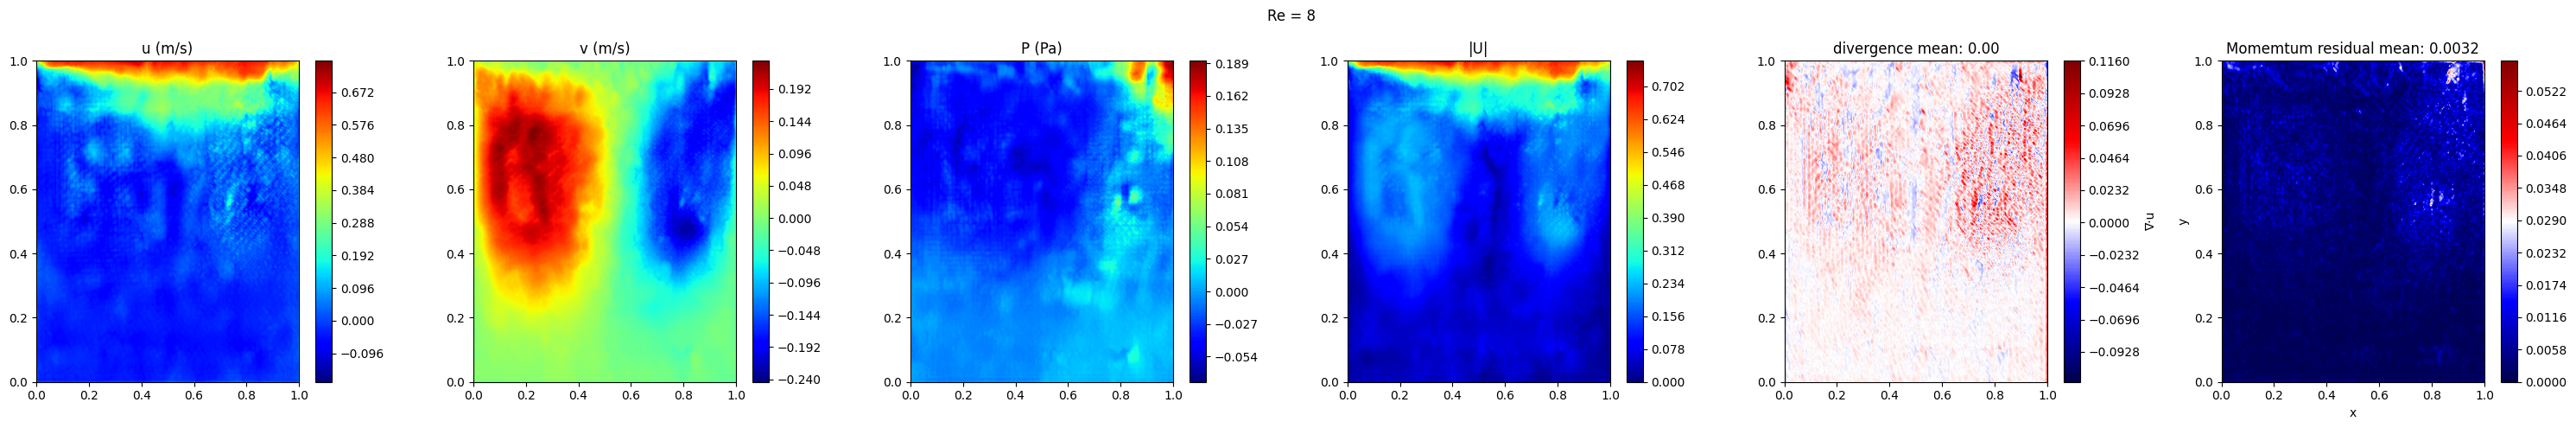

In [33]:
u, v, P, divergence, momentum_res, mag = predict(re_value = 8, sample_fn = sample_ddim, 
                                   re_mean = RE_MEAN, re_std = RE_STD, 
                                   u_mean = U_MEAN,   u_std = U_STD, 
                                   v_mean = V_MEAN,   v_std = V_STD, 
                                   P_mean = P_MEAN,   P_std = P_STD,
                                   grid_size = 256,
                                   device = "cpu", plot = True
                                   )

1000it [00:59, 16.89it/s]


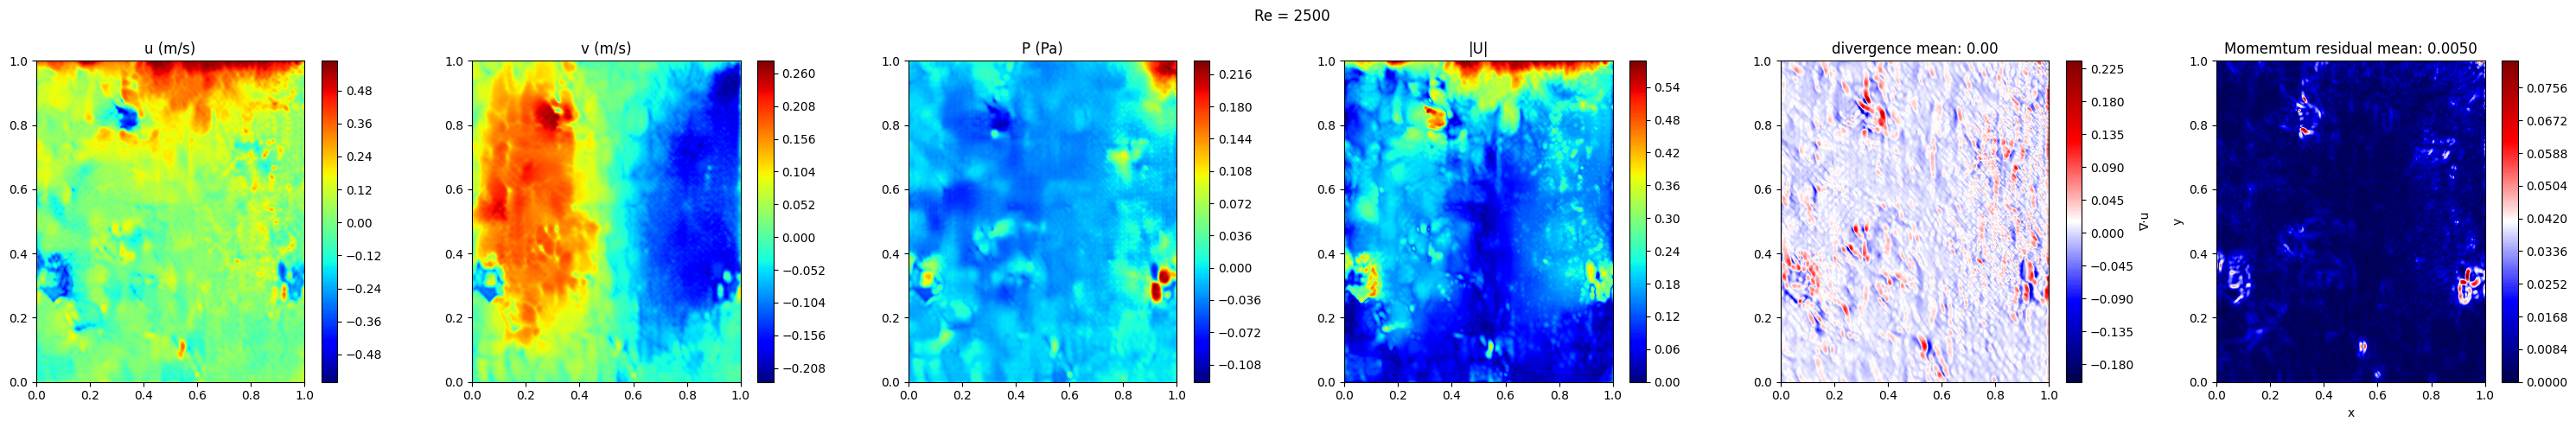

In [39]:
u, v, P, divergence, momentum_res, mag = predict(re_value = 2500, sample_fn = sample, 
                                                 re_mean = RE_MEAN, re_std = RE_STD, 
                                                 u_mean = U_MEAN,   u_std = U_STD, 
                                                 v_mean = V_MEAN,   v_std = V_STD, 
                                                 P_mean = P_MEAN,   P_std = P_STD,
                                                 grid_size = 256,
                                                 device = "cpu", plot = True
                                                 )  

In [12]:
from torch.utils.data import Dataset, DataLoader
from Data import dataset_cfd

In [13]:
dataset    = dataset_cfd.dataset_csv(folder = f"{ROOT}/Data/Problems/{config['Data']['name']}", meta = "Lid_Driven")
dataloader = DataLoader(dataset, batch_size = 1, shuffle=True, num_workers=2)

In [14]:
# worst = -float("inf")
# worst_file = None
# for idx in tqdm(range(len(dataset))):
#     uvp, num, mask = dataset[idx]
#     m = np.abs(uvp).max()
#     if m > worst:
#         worst = m
#         worst_file = dataset.all_pths[idx]
#         # print(worst, worst_file)
# print(worst, worst_file)

In [15]:
# min_val = torch.tensor(torch.inf)
# max_val = torch.tensor(-torch.inf)

# for uvp_grids, r, mask in tqdm(dataloader):
#     min_val = min(min_val, uvp_grids.min())
#     max_val = max(max_val, uvp_grids.max())

# min_val, max_val

In [16]:
uvp_grids, r, mask = next(iter(dataloader))

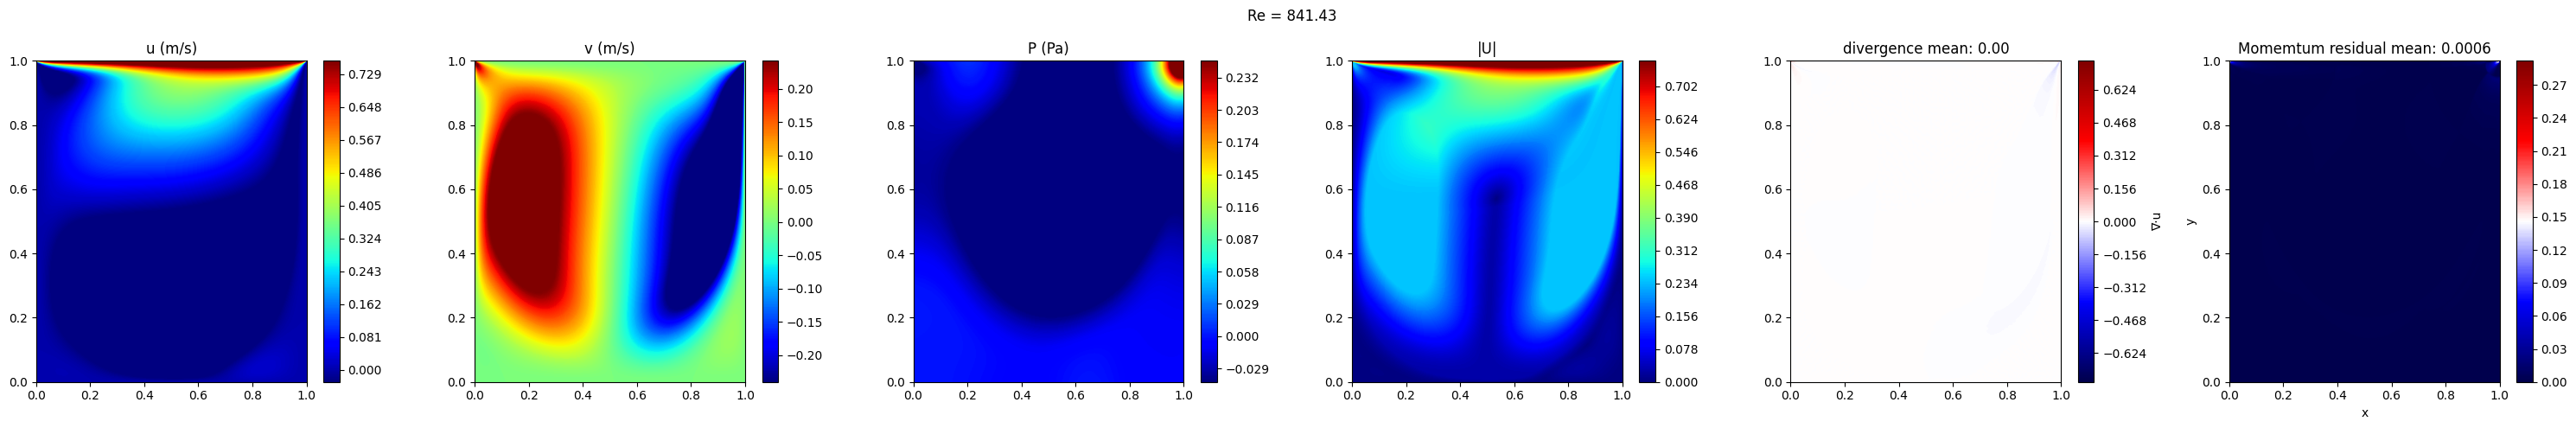

In [17]:
uvp_grid = uvp_grids[0]
re_value = (r.item() * RE_STD) + RE_MEAN

u = (uvp_grid[0] * U_STD) + U_MEAN
v = (uvp_grid[1] * V_STD) + V_MEAN
p = (uvp_grid[2] * P_STD) + P_MEAN

mag = np.sqrt(u**2 + v**2)

du_dx = np.gradient(u, axis = 1) # derivative along x (cols)
du_dy = np.gradient(u, axis = 0)
dv_dy = np.gradient(v, axis = 0) # derivative along y (rows)
dv_dx = np.gradient(v, axis = 1)


d2u_dx2 = np.gradient(du_dx, axis = 1)
d2u_dy2 = np.gradient(du_dy, axis = 0)
d2v_dy2 = np.gradient(dv_dy, axis = 0)
d2v_dx2 = np.gradient(dv_dx, axis = 1)


dP_dx = np.gradient(p, axis = 1)
dP_dy = np.gradient(p, axis = 0)


momentum_res_x = (1 * ((u * du_dx) + (v * du_dy))) + dP_dx + (1/re_value) * (d2u_dx2 + d2u_dy2)
momentum_res_y = (1 * ((u * dv_dx) + (v * dv_dy))) + dP_dy + (1/re_value) * (d2v_dx2 + d2v_dy2)

momentum_res =  (momentum_res_x ** 2 + momentum_res_y ** 2)**0.5

divergence = du_dx + dv_dy


# u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
# v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

# plot
x_grid = np.linspace(0, 1, 256)
y_grid = np.linspace(0, 1, 256)


fig, axes = plt.subplots(1, 6, figsize=(30, 5))

# u
c0 = axes[0].contourf(x_grid, y_grid, u, levels=300, cmap="jet")
fig.colorbar(c0, ax=axes[0])
axes[0].set_title("u (m/s)")

# v
c1 = axes[1].contourf(x_grid, y_grid, v, levels=300, cmap="jet")
fig.colorbar(c1, ax=axes[1])
axes[1].set_title("v (m/s)")

# p
c2 = axes[2].contourf(x_grid, y_grid, p, levels=300, cmap="jet")
fig.colorbar(c2, ax=axes[2])
axes[2].set_title("P (Pa)")

# mag
c3 = axes[3].contourf(x_grid, y_grid, mag, levels=300, cmap="jet")
fig.colorbar(c3, ax=axes[3])
axes[3].set_title("|U|")


c4 = axes[4].contourf(x_grid, y_grid, divergence, levels=300, cmap="seismic")
fig.colorbar(c4, ax=axes[4], label="∇·u")
axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")


div_m = axes[5].contourf(x_grid, y_grid, momentum_res, levels=300, cmap="seismic")
plt.colorbar(div_m, ax=axes[5])
axes[5].set_title(f"Momemtum residual mean: {momentum_res.mean():.4f}")
axes[5].set_xlabel("x")
axes[5].set_ylabel("y")

plt.suptitle(f"Re = {re_value}")
plt.tight_layout()
plt.show()

In [18]:
mu, logvar = vae.encode(uvp_grids)
recon = vae.decode(mu)

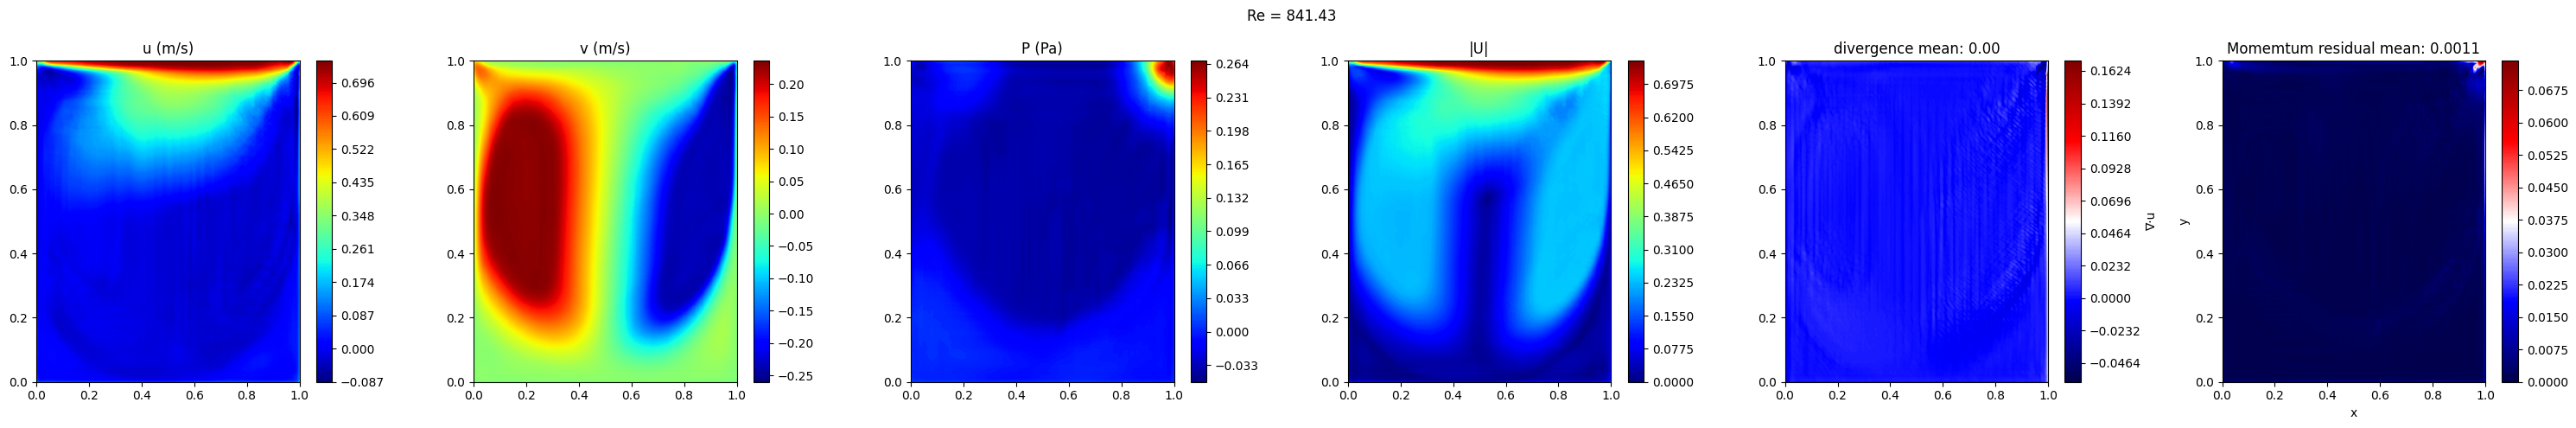

In [19]:
uvp_grid = recon[0]
re_value = (r.item() * RE_STD) + RE_MEAN

u = (uvp_grid[0] * U_STD) + U_MEAN
v = (uvp_grid[1] * V_STD) + V_MEAN
p = (uvp_grid[2] * P_STD) + P_MEAN

mag = np.sqrt(u**2 + v**2)

du_dx = np.gradient(u, axis = 1) # derivative along x (cols)
du_dy = np.gradient(u, axis = 0)
dv_dy = np.gradient(v, axis = 0) # derivative along y (rows)
dv_dx = np.gradient(v, axis = 1)


d2u_dx2 = np.gradient(du_dx, axis = 1)
d2u_dy2 = np.gradient(du_dy, axis = 0)
d2v_dy2 = np.gradient(dv_dy, axis = 0)
d2v_dx2 = np.gradient(dv_dx, axis = 1)


dP_dx = np.gradient(p, axis = 1)
dP_dy = np.gradient(p, axis = 0)


momentum_res_x = (1 * ((u * du_dx) + (v * du_dy))) + dP_dx + (1/re_value) * (d2u_dx2 + d2u_dy2)
momentum_res_y = (1 * ((u * dv_dx) + (v * dv_dy))) + dP_dy + (1/re_value) * (d2v_dx2 + d2v_dy2)

momentum_res =  (momentum_res_x ** 2 + momentum_res_y ** 2)**0.5

divergence = du_dx + dv_dy


# u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
# v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

# plot
x_grid = np.linspace(0, 1, 256)
y_grid = np.linspace(0, 1, 256)


fig, axes = plt.subplots(1, 6, figsize=(30, 5))

# u
c0 = axes[0].contourf(x_grid, y_grid, u, levels=300, cmap="jet")
fig.colorbar(c0, ax=axes[0])
axes[0].set_title("u (m/s)")

# v
c1 = axes[1].contourf(x_grid, y_grid, v, levels=300, cmap="jet")
fig.colorbar(c1, ax=axes[1])
axes[1].set_title("v (m/s)")

# p
c2 = axes[2].contourf(x_grid, y_grid, p, levels=300, cmap="jet")
fig.colorbar(c2, ax=axes[2])
axes[2].set_title("P (Pa)")

# mag
c3 = axes[3].contourf(x_grid, y_grid, mag, levels=300, cmap="jet")
fig.colorbar(c3, ax=axes[3])
axes[3].set_title("|U|")


c4 = axes[4].contourf(x_grid, y_grid, divergence, levels=300, cmap="seismic")
fig.colorbar(c4, ax=axes[4], label="∇·u")
axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")

div_m = axes[5].contourf(x_grid, y_grid, momentum_res, levels=300, cmap="seismic")
plt.colorbar(div_m, ax=axes[5])
axes[5].set_title(f"Momemtum residual mean: {momentum_res.mean():.4f}")
axes[5].set_xlabel("x")
axes[5].set_ylabel("y")

plt.suptitle(f"Re = {re_value}")
plt.tight_layout()
plt.show()

In [20]:
# pick one actual training example
images, numbers, mask = next(iter(dataloader))
true_number = numbers[0].item()      # already normalized, matches training distribution

with torch.no_grad():
    mu, logvar = vae.encode(images.to(device))
    z_true = mu[0:1]                 # ground truth latent, no reparam noise

# sample from scratch using that exact training Re
img = sample(32, dit, vae, device, scheduler, true_number)

# compare img (decoded generation) against vae.decode(z_true) (ground truth)

1000it [00:51, 19.54it/s]


In [21]:
vae.decode(z_true)

tensor([[[[-0.4951, -0.6253, -0.7034,  ..., -0.6781, -0.5958, -0.3656],
          [-0.6637, -0.8124, -0.9230,  ..., -0.8678, -0.7489, -0.5338],
          [-0.7310, -0.9009, -1.0061,  ..., -0.9064, -0.8030, -0.5531],
          ...,
          [-0.1583, -0.1167, -0.0903,  ..., -0.1152, -0.4531, -0.3418],
          [ 0.0553,  0.2000,  0.2420,  ...,  0.4840,  0.1471,  0.1425],
          [ 0.1942,  0.3693,  0.4651,  ...,  0.5857,  0.2291,  0.0525]],

         [[-0.2192, -0.2137, -0.1700,  ..., -0.3100, -0.2973, -0.2289],
          [-0.2839, -0.2413, -0.1948,  ..., -0.3562, -0.3522, -0.3019],
          [-0.2432, -0.1712, -0.1196,  ..., -0.2881, -0.3055, -0.2718],
          ...,
          [ 0.4618,  1.0303,  1.4245,  ..., -2.8447, -2.4181, -1.4412],
          [ 0.3650,  0.8637,  1.1320,  ..., -1.8421, -1.6065, -0.9130],
          [ 0.2602,  0.6123,  0.7748,  ..., -0.7812, -0.6880, -0.4455]],

         [[-0.4003, -0.4312, -0.4507,  ..., -0.6319, -0.6118, -0.4690],
          [-0.4872, -0.4950, -

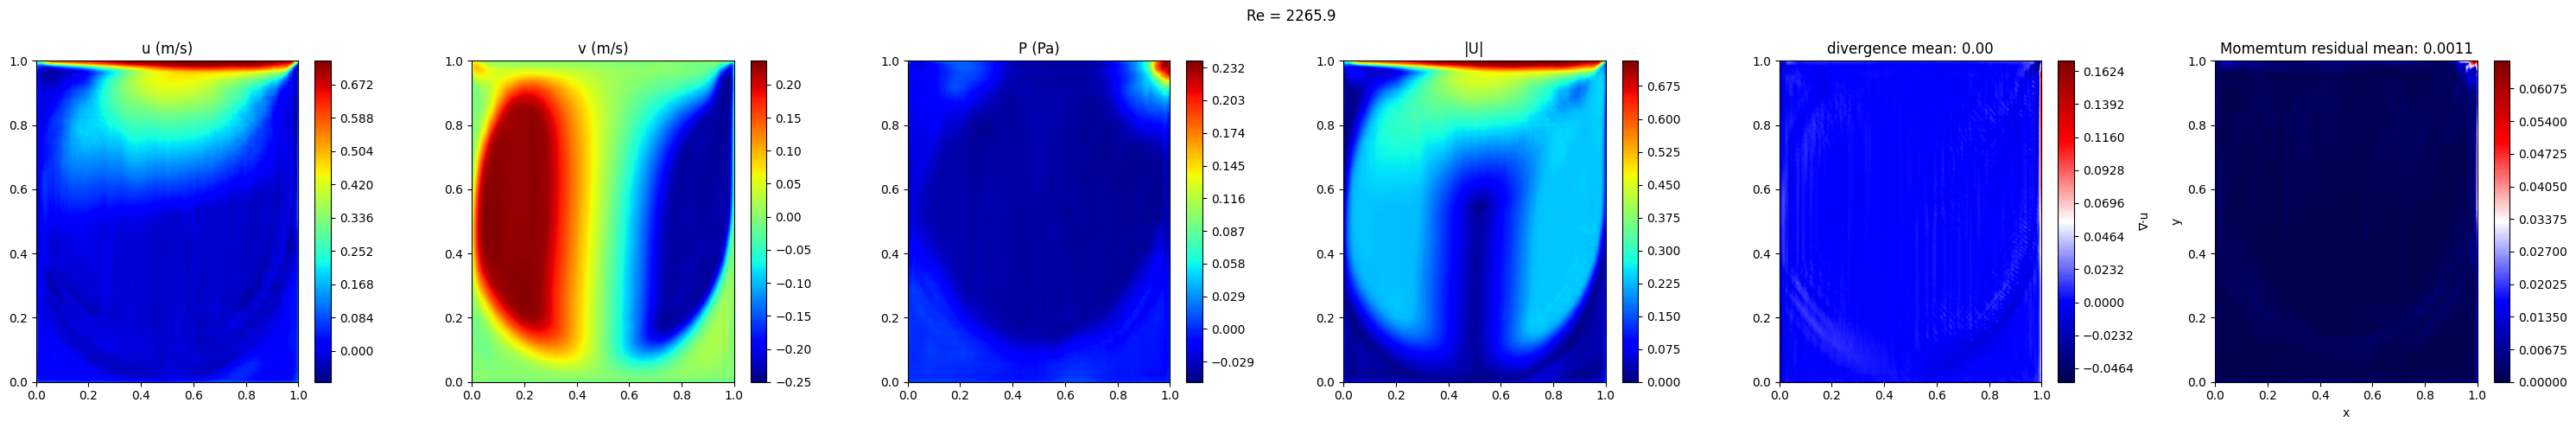

In [22]:
uvp_grid = vae.decode(z_true)[0]
re_value = (numbers.item() * RE_STD) + RE_MEAN

u = (uvp_grid[0] * U_STD) + U_MEAN
v = (uvp_grid[1] * V_STD) + V_MEAN
p = (uvp_grid[2] * P_STD) + P_MEAN

mag = np.sqrt(u**2 + v**2)

du_dx = np.gradient(u, axis = 1) # derivative along x (cols)
du_dy = np.gradient(u, axis = 0)
dv_dy = np.gradient(v, axis = 0) # derivative along y (rows)
dv_dx = np.gradient(v, axis = 1)


d2u_dx2 = np.gradient(du_dx, axis = 1)
d2u_dy2 = np.gradient(du_dy, axis = 0)
d2v_dy2 = np.gradient(dv_dy, axis = 0)
d2v_dx2 = np.gradient(dv_dx, axis = 1)


dP_dx = np.gradient(p, axis = 1)
dP_dy = np.gradient(p, axis = 0)


momentum_res_x = (1 * ((u * du_dx) + (v * du_dy))) + dP_dx + (1/re_value) * (d2u_dx2 + d2u_dy2)
momentum_res_y = (1 * ((u * dv_dx) + (v * dv_dy))) + dP_dy + (1/re_value) * (d2v_dx2 + d2v_dy2)

momentum_res =  (momentum_res_x ** 2 + momentum_res_y ** 2)**0.5

divergence = du_dx + dv_dy


# u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
# v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

# plot
x_grid = np.linspace(0, 1, 256)
y_grid = np.linspace(0, 1, 256)


fig, axes = plt.subplots(1, 6, figsize=(30, 5))

# u
c0 = axes[0].contourf(x_grid, y_grid, u, levels=300, cmap="jet")
fig.colorbar(c0, ax=axes[0])
axes[0].set_title("u (m/s)")

# v
c1 = axes[1].contourf(x_grid, y_grid, v, levels=300, cmap="jet")
fig.colorbar(c1, ax=axes[1])
axes[1].set_title("v (m/s)")

# p
c2 = axes[2].contourf(x_grid, y_grid, p, levels=300, cmap="jet")
fig.colorbar(c2, ax=axes[2])
axes[2].set_title("P (Pa)")

# mag
c3 = axes[3].contourf(x_grid, y_grid, mag, levels=300, cmap="jet")
fig.colorbar(c3, ax=axes[3])
axes[3].set_title("|U|")


c4 = axes[4].contourf(x_grid, y_grid, divergence, levels=300, cmap="seismic")
fig.colorbar(c4, ax=axes[4], label="∇·u")
axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")

div_m = axes[5].contourf(x_grid, y_grid, momentum_res, levels=300, cmap="seismic")
plt.colorbar(div_m, ax=axes[5])
axes[5].set_title(f"Momemtum residual mean: {momentum_res.mean():.4f}")
axes[5].set_xlabel("x")
axes[5].set_ylabel("y")

plt.suptitle(f"Re = {re_value}")
plt.tight_layout()
plt.show()